# 06 Classification dengan KNN (K-Neirest Neighbours)

- KNN adalah model machine learning yang dapat digunakan untuk melakukan prediksi berdasarkan kedekatan karakteristik sejumlah tetangga terdekat.
- Prediksi yang dilakukan dapat diterapkan baik pada classification maupun regression tasks.

Refresensi : https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm

---

## Sample Dataset

Disini pertama-tama kita akan persiapkan terlebih dahulu dataset yang akan kita pergunakan dalam sesi pembelajaran ini. Kali ini kita akan membentuk dataset yang berisi daftar **berat** dan **tinggi** badan sejumlah partisipan beserta _gender_ atau **jenis kelaminya**. Dataset ini akan kita tampung ke dalam format Pandas DataFrame.

In [1]:
import pandas as pd

In [2]:
# dictionary 3 keys
sensus = {
    "tinggi" : [158, 170, 183, 191, 155, 163, 180, 158, 178],
    "berat" : [64, 86, 84, 80, 49, 59, 67, 54, 67],
    "jk" : [
        "pria", "pria", "pria", "pria", "wanita", "wanita", "wanita", "wanita", "wanita",
    ]
}

# mengubah dictionary ke Pandas DataFrame
sensus_df = pd.DataFrame(sensus)
sensus_df

,tinggi,berat,jk
0,158,64,pria
1,170,86,pria
2,183,84,pria
3,191,80,pria
4,155,49,wanita
5,163,59,wanita
6,180,67,wanita
7,158,54,wanita
8,178,67,wanita


Kalau kita lihat dari hasil dataset diatas yang diubah dalam bentuk Pandas DataFrame, terdiri dari 3 buah kolom yaitu **tinggi**, **berat** dan **jk** (jenis kelamin). 

Dalam sesi pembelajaran kita kali ini, kita akan membentuk model machine learning sederhana yang dapat digunakan untuk **`memprediksi gender` atau jenis kelamin seseorang `berdasarkan` data `tinggi` dan berat `badannya`.** 

Dengan kata lain, disini **data `tinggi` dan `berat` akan berperan `sebagai features`, sedangkan `jk (jenis kelamin)` akan berperan sebagai `target`.** 

---

## Visualisasi Data 

Disini kita akan coba visualisasikan dataset sensus yang telah kita bentuk sebelumnya ke dalam scatterplot. Dimana sumbu X akan berasosiasi dengan tinggi badan, sedangkan sumbu y akan berasosiasi dengan berat badan. 

In [3]:
import seaborn as sns

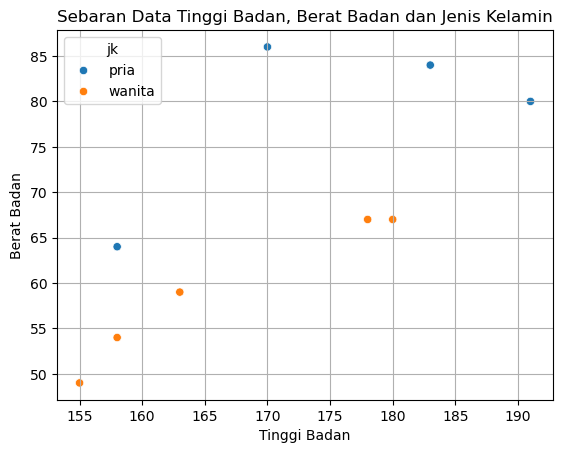

In [4]:
ax = sns.scatterplot(data=sensus_df, x='tinggi', y='berat', hue='jk')

ax.set(
    title = "Sebaran Data Tinggi Badan, Berat Badan dan Jenis Kelamin",
    xlabel = "Tinggi Badan",
    ylabel = "Berat Badan"
)

ax.grid(True)

Nah itu visualisasinya, kalau kita hitung ada 9 marker atau tanda titik berwarnanya. Dimana 9 marker itu berasosiasi dengan setiap baris dari dataset `sensus_df` kita sebelumnya. 

Nah tujuan kita selanjutnya adalah, apabila ada point atau baris baru yang datanya memuat berat dan tinggi badan, kita akan memprediksi apakah data baru tersebut masuk dalam kategori pria atau wanita. 

---

## Classification dengan KNN

Setelah kita memahami kontesk dataset dan juga permasalahannya, kita akan coba menerapkan KNN atau K-Nearest Neighbors untuk melakukan klasifikasi jenis kelamin berdasarkan data tinggi dan berat badan. 

Sesuai dengan namanya, machine learning ini akan melakukan prediksi yang dalam kasus ini jenis kelamin berdasarkan kemiripan karakteristik atau features dengan dataset yang kita miliki. 

KNN juga termasuk salah satu model machine learning yang wajib dikuasai. 

### Preprocesing Dataset

Untuk mengambil data training, kita bisa ambil kolom `tinggi` dan `berat`. 

In [5]:
import numpy as np

In [6]:
X_train = sensus_df[['tinggi', 'berat']]

In [7]:
X_train

,tinggi,berat
0,158,64
1,170,86
2,183,84
3,191,80
4,155,49
5,163,59
6,180,67
7,158,54
8,178,67


Nah `X_train` diatas berisi sekumpulan nilai features yg tipe datanya sudah dalam bentuk numerik, sehingga sudah siap untuk kita gunakan untuk proses training set.

Lalu untuk `y_train` sebagai target, kita bisa langsung pilih kolom `jk`

In [8]:
y_train = sensus_df['jk']

In [9]:
y_train

0      pria
1      pria
2      pria
3      pria
4    wanita
5    wanita
6    wanita
7    wanita
8    wanita
Name: jk, dtype: object

Jika kita lihat nilai targetnya, disini tipe datanya _masih berupa string_. Sebenarnya untuk kasus `klasifikasi dengan KNN`, target dengan tipe data data string `tetap bisa di proses dengan baik`. Hanya saja kita akan menghadapi **kendala sewaktu melakukan evaluasi model**. 

Oleh karenanya kita akan konversikan nilai string `pria` dan `wanita` menjadi nilai numerik. Karena jenis kelamin hanya terdiri dari dua nilai, maka kita bisa memanfaatkan **Binarizer** untuk melakukan konversi nilai `string menjadi nilai numeric binary. `

Kita bisa memanfaatkan kelas preprocessing yang disertakan oleh Scikit-Learn, yaitu Binarizer. 

In [10]:
from sklearn.preprocessing import LabelBinarizer

Lalu berikutnya kita akan coba bentuk objek kelas dari Binarizer ini

In [11]:
lb = LabelBinarizer()

Lalu objek lb (LabelBinarizer) ini akan kita manfaatkan untuk melakukan transformasi data yang terdapat dalam variable `y_train` tadi (wanita pria). 

In [12]:
y_train = lb.fit_transform(y_train)

In [13]:
y_train

array([[0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1]])

Bisa nampak disini nilainya hanya ada 2 yaitu 0 dan 1. 

Nah `0` disini akan mempresentasikan data `pria`, sedangkan nilai `1` nya akan mempresentasikan data wanita. 

Hanya saja kalau kita perhatikan kembali setelah melakukan transformasi menggunakan **Binarizer**, `y_train` berubah menjadi array 2 dimensi, sehingga kita perlu mengembalikannya ke dalam bentuk 1 dimensi.

In [14]:
y_train = lb.transform(y_train).flatten()

In [15]:
print(f"y : {y_train}")

y : [0 0 0 0 0 0 0 0 0]


Oke, sudah berubah menjadi array 1 dimensi lagi

Maka dengan itu sekarang sekumpulan features dan target sudah siap untuk digunakan dalam training model. 

---

### Training KNN Classification Model

Setelah training set -nya sudah kita persiapkan, selanjutnya kita akan melangkah ke proses training model. Kali ini model machine learning yang akan kita gunakan adalah KNN. Kita coba dulu import estimatornya

In [16]:
from sklearn.neighbors import KNeighborsClassifier

Kita sengaja memilih `KNeighborsClassifier` karena kita akan menggunakan KNN ini untuk melakukan Classification Task. 

Terdapat satu parameter yang harus kita spesifikan nilainya, yaitu parameter `K`. Untuk kasus kita kali ini, nilai parameternya akan kita set sebagai `3`.

In [17]:
K = 3

Nah nilai parameter `K` digunakan untuk menentukan jumlah tetangga terdekat yang akan dilibatkan untuk proses prediksi. Dan untuk kasus kita kali ini adalah 3 tetangga terdekat.

Setelah nilai `K` nya sudah kita tentukan, berikutnya kita akan bentuk objek dari kelas `KNeighborsClassifier`. Nah objek KNeighborsClassifier ini membutuhkan satu parameter yaitu `n_neighbors` yang akan kita beri nilai `K`

In [18]:
model = KNeighborsClassifier(n_neighbors=K)

Lalu berikutnya setelah objek KNeighbors Classifier nya kita bentuk, kita tampung dalam variable model. Untuk selanjutnya kita training dengan memanfaatkan `X_train` dan `y_train` yang sudah kita persiapkan sebelumnya. 

In [19]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Nah setelah modelnya kita training, maka **status dari model ini adalah trained model atau model yang sudah di training**. Disini proses training-nya terbilang cepat karena ukuran dataset yang kita miliki juga terbilang sangat kecil. 

---

### Prediksi Jenis Kelamin

Setelah model KNeighborsClassifier kita training, tahapan selanjutnya kita akan gunakan trend model ini untuk melakukan **`prediksi gender` atau `jenis kelamin` berdasarkan `data tinggi` dan `berat` badan.**

Disini kita siapkan terlebih dahulu data baru yang akan digunakan untuk prediksi. 

In [20]:
data_baru = {
    'tinggi' : [155],
    'berat' : [70]
}

Semisal disini kita memiliki data baru dimana `tinggi` nya $155$ dan `berat` nya $70$ yang akan kita prediksi jenis kelaminnya apakah pria atau wanita. 

Karena featuresnya harus kita bentuk dulu atau kita _bundle_ dulu menjadi suatu Numpy Array atau Pandas DataFrame. Karena kita ingin menggunakan Pandas, kita bisa lakukan hal berikut :

In [21]:
X_new = pd.DataFrame(data_baru)

In [22]:
X_new

,tinggi,berat
0,155,70


Oke sudah terlihat ya, satu baris baru yang terdiri dari 2 kolom.

Nah setelah data tinggi dan berat badannya siap, selanjutnya kita akan melakukan prediksi gender dengan memanfaatkan model KNN Classifier yang sudah kita training sebelumnya. 

In [23]:
y_new = model.predict(X_new)

In [24]:
y_new

array([0])

itu dia hasilnya. Disini kita bisa bahwa data tinggi badan 155 dengan berat badan 70 akan diprediksi memiliki jenis kelamin 0. 

Nah kalau kita lupa 1 itu pria atau wanita, kita bisa panggil kembali label Binarizer-nya. 

In [25]:
lb.inverse_transform(y_new)

array(['pria'], dtype='<U6')

Nah itu dia hasil invers-nya. Disini kita bisa tau bahwa nilai 0 untuk target itu berkorelasi dengan jenis kelamin `pria`. Atau dengan kata lain tinggi badan = 155, dan berat badan = 70 diprediksi sebagai data pria oleh model yang kita prediksi sebelumnya. 

---

### Visualisasi Nearest Neighbors

kita bisa menambahkan data baru dan mencoba melihat kira-kira dekat dengan kelompok atau klasifikasi yang mana

In [26]:
data_baru = pd.DataFrame({
    'tinggi': [155],
    'berat': [70],
    'jk': ['misterius']
})

In [27]:
df_plot = pd.concat([sensus_df, data_baru], ignore_index=True)

<Axes: xlabel='tinggi', ylabel='berat'>

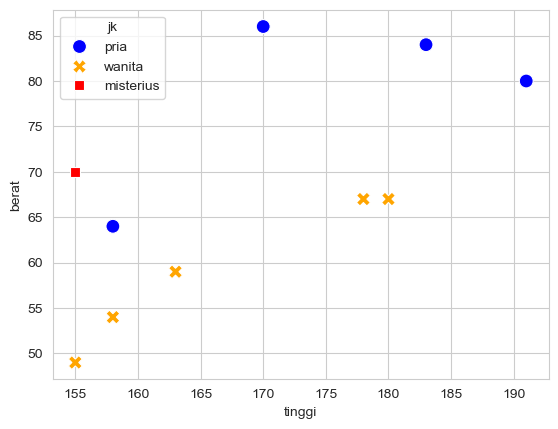

In [28]:
sns.set_style("whitegrid")
sns.scatterplot(data=df_plot, x='tinggi', y='berat', hue='jk', style='jk', 
                s=100, palette={'pria': 'blue', 'wanita': 'orange', 'misterius': 'red'})